In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from datetime import datetime
import os
import qlbm
from qlbm.initial_conditions import *
from qlbm.visualization import *

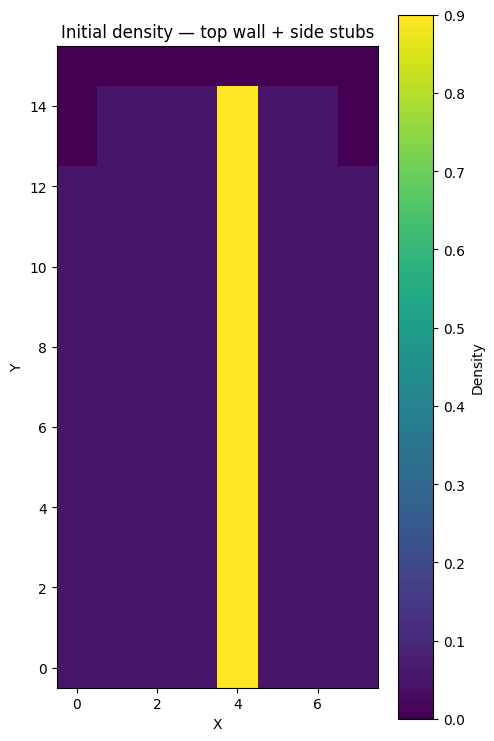

In [2]:
# ── Lattice ──────────────────────────────────────────────────────────
EXPERIMENT_NAME = "BoundaryConditions2D_TopWall"
NUM_ITERATIONS  = 15

# D2Q5
links          = [[0, 0], [1, 0], [-1, 0], [0, 1], [0, -1]]
weights        = [1/3, 1/6, 1/6, 1/6, 1/6]
speed_of_sound = 1 / np.sqrt(3)

# ── Grid & initial conditions ─────────────────────────────────────────
GRID_SIZE = (8, 16)
Nx, Ny = GRID_SIZE

initial_density = np.full(GRID_SIZE, 0.05)
initial_density[Nx // 2, :] = 0.9

# Zero out wall sites: top wall + top 2 cells of side walls
initial_density[:, -1] = 0.0          # top wall
initial_density[0, -3:] = 0.0         # left side stub (2 cells)
initial_density[-1, -3:] = 0.0        # right side stub (2 cells)

# ── Boundary conditions ────────────────────────────────────────────────
# Minimal BC: top wall + 2 cells of each side wall near the top corner.
nv = len(links)
bc = np.zeros((Nx, Ny, nv, nv))
for x in range(Nx):
    for y in range(Ny):
        bc[x, y] = np.eye(nv)

link_dirs = {tuple(l): i for i, l in enumerate(links)}
STAT = link_dirs[(0, 0)]    # 0
RIGHT = link_dirs[(1, 0)]   # 1
LEFT = link_dirs[(-1, 0)]   # 2
UP = link_dirs[(0, 1)]      # 3
DOWN = link_dirs[(0, -1)]   # 4

REFLECT_FRAC = 0.2

def apply_wall(bc, x, y, perp_in, perp_out, blocked):
    """Redirect perp_in: reflect_frac back, rest split among safe tangentials."""
    safe = [t for t in range(nv) if t not in (perp_in, perp_out, STAT) and t not in blocked]
    bc[x, y, perp_in, perp_in] = 0.0
    bc[x, y, perp_out, perp_in] = REFLECT_FRAC
    if safe:
        frac = (1.0 - REFLECT_FRAC) / len(safe)
        for t in safe:
            bc[x, y, t, perp_in] = frac
    else:
        bc[x, y, perp_out, perp_in] = 1.0

SIDE_WALL_DEPTH = 2  # how many cells of side wall below the top corner

# Top wall: BC nodes at y=Ny-2, for all interior x
for x in range(1, Nx - 1):
    apply_wall(bc, x, Ny - 2, UP, DOWN, blocked=set())

# Left side wall stub: BC nodes at x=1, for top few rows
for y in range(Ny - 2, Ny - 2 - SIDE_WALL_DEPTH, -1):
    blocked = {UP} if y == Ny - 2 else set()  # corner: UP already redirected
    apply_wall(bc, 1, y, LEFT, RIGHT, blocked=blocked)

# Right side wall stub: BC nodes at x=Nx-2, for top few rows
for y in range(Ny - 2, Ny - 2 - SIDE_WALL_DEPTH, -1):
    blocked = {UP} if y == Ny - 2 else set()
    apply_wall(bc, Nx - 2, y, RIGHT, LEFT, blocked=blocked)

boundary_conditions = bc

# ── Velocity field — uniform upward push ───────────────────────────────
velocity = np.zeros((2, *GRID_SIZE))
velocity[1, :, :] = 0.3

config = [
    (NUM_ITERATIONS, velocity, links, weights, speed_of_sound, boundary_conditions),
]

# Quick sanity-check plot
fig, ax = plt.subplots(figsize=(5, 8))
im = ax.imshow(initial_density.T, cmap='viridis', origin='lower')
plt.colorbar(im, ax=ax, label='Density')
ax.set_title('Initial density — top wall + side stubs')
ax.set_xlabel('X'); ax.set_ylabel('Y')
plt.tight_layout(); plt.show()

In [3]:
timestamp  = datetime.now().strftime("%Y%m%d_%H%M%S")
dirname    = f"experiments/{EXPERIMENT_NAME}_{timestamp}"
os.makedirs(dirname, exist_ok=True)

classical_csv = f"{dirname}/classical.csv"
quantum_csv   = f"{dirname}/quantum.csv"

qlbm.simulate_flow_classical(initial_density, config, classical_csv)
qlbm.simulate_flow(initial_density, config, quantum_csv)

Classical simulation: iterations 0-15/15
Classical Iteration 1/15
Classical Iteration 2/15
Classical Iteration 3/15
Classical Iteration 4/15
Classical Iteration 5/15
Classical Iteration 6/15
Classical Iteration 7/15
Classical Iteration 8/15
Classical Iteration 9/15
Classical Iteration 10/15
Classical Iteration 11/15
Classical Iteration 12/15
Classical Iteration 13/15
Classical Iteration 14/15
Classical Iteration 15/15
Classical simulation complete. Results saved to experiments/BoundaryConditions2D_TopWall_20260418_172418/classical.csv
Pre-building all circuit components for 1 configuration(s)...
  Building components for configuration 1/1...
Using SVD decomposition for non-diagonal collision matrix
Decomposition complete
Added manually-constructed controlled unitaries to circuit
    Components built and transpiled.
Pre-building complete. 1 unique component set(s) created.
Starting simulation...

Configuration 1/1: iterations 1-15/15
Iteration 1 running...
Iteration 2 running...
Iterati

/tmp/ipykernel_39497/3399280762.py:24: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.88, 1.0])


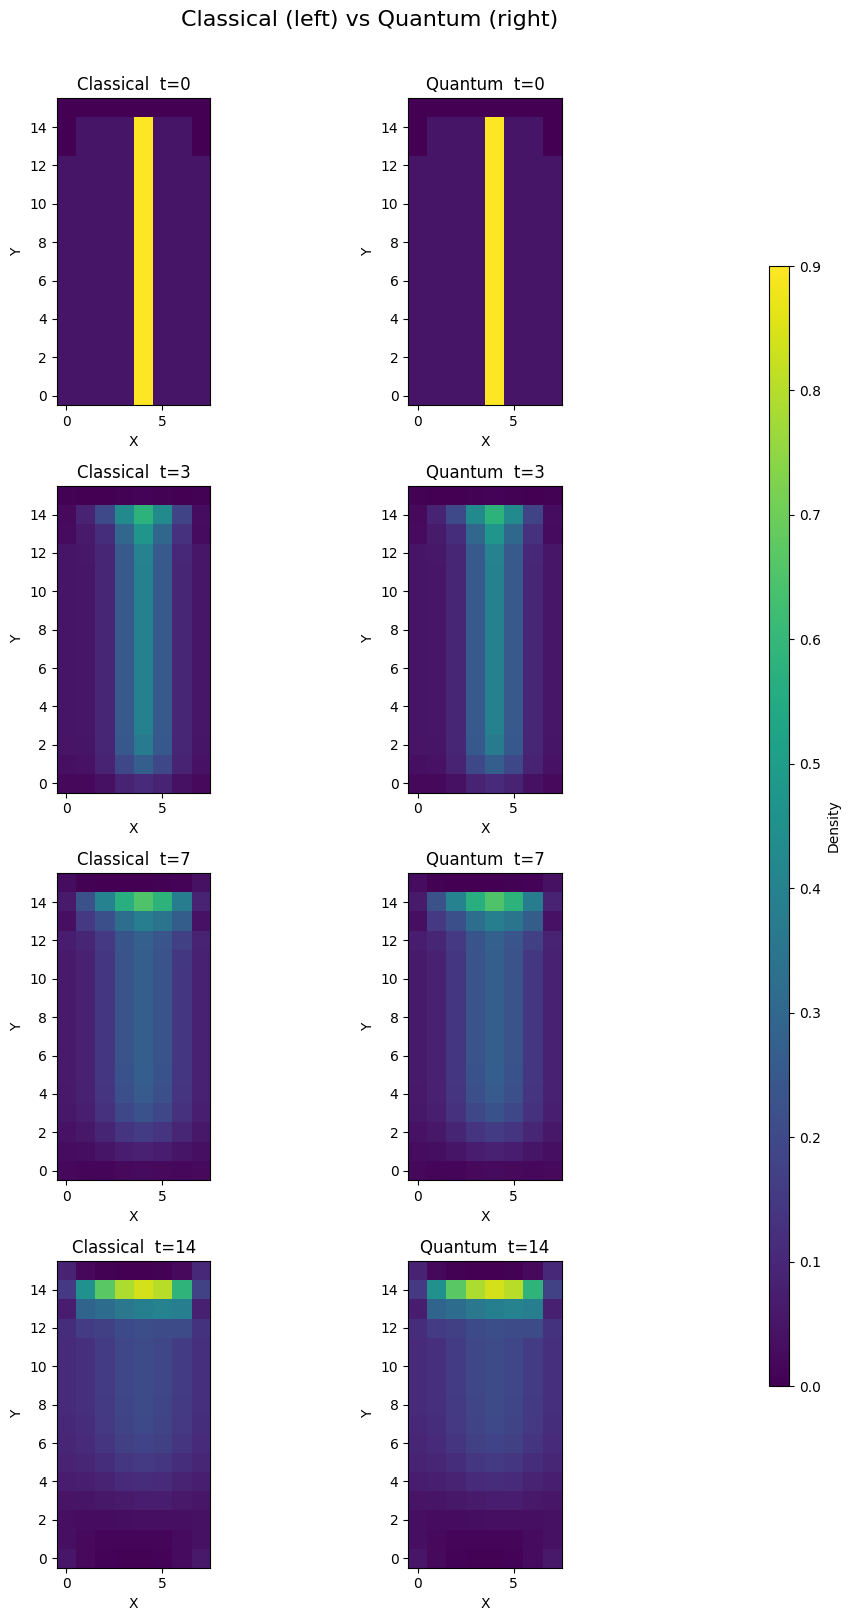

Snapshots saved to experiments/BoundaryConditions2D_TopWall_20260418_172418/snapshots.png


In [4]:
# Side-by-side snapshots (classical vs quantum)
snapshot_iters = [0, NUM_ITERATIONS // 4, NUM_ITERATIONS // 2, NUM_ITERATIONS - 1]

df_c = pd.read_csv(classical_csv, header=None)
df_q = pd.read_csv(quantum_csv, header=None)

vmin = min(df_c.values.min(), df_q.values.min())
vmax = max(df_c.values.max(), df_q.values.max())

fig, axes = plt.subplots(len(snapshot_iters), 2, figsize=(10, 4 * len(snapshot_iters)))
fig.suptitle('Classical (left) vs Quantum (right)', fontsize=16, y=1.01)

for row, t in enumerate(snapshot_iters):
    for col, (df, label) in enumerate([(df_c, 'Classical'), (df_q, 'Quantum')]):
        ax = axes[row, col]
        frame = df.iloc[t].values.reshape(GRID_SIZE, order='F')
        im = ax.imshow(frame.T, cmap='viridis', origin='lower', vmin=vmin, vmax=vmax)
        ax.set_title(f'{label}  t={t}')
        ax.set_xlabel('X'); ax.set_ylabel('Y')

fig.subplots_adjust(right=0.88)
cbar_ax = fig.add_axes([0.90, 0.15, 0.02, 0.7])
fig.colorbar(im, cax=cbar_ax, label='Density')
plt.tight_layout(rect=[0, 0, 0.88, 1.0])
plt.savefig(f"{dirname}/snapshots.png", dpi=300, bbox_inches='tight')
plt.show()
print(f"Snapshots saved to {dirname}/snapshots.png")

In [5]:
# RMSE between classical and quantum over time
qlbm.save_rmse_comparison(classical_csv, quantum_csv, GRID_SIZE, f"{dirname}/rmse.png")

RMSE comparison saved to experiments/BoundaryConditions2D_TopWall_20260418_172418/rmse.png


In [6]:
# Animated classical result
animate_density_evolution(GRID_SIZE, classical_csv, interval=100, boundary_nodes=boundary_mask(boundary_conditions))

In [7]:
# Animated quantum result
animate_density_evolution(GRID_SIZE, quantum_csv, interval=100, boundary_nodes=boundary_mask(boundary_conditions))

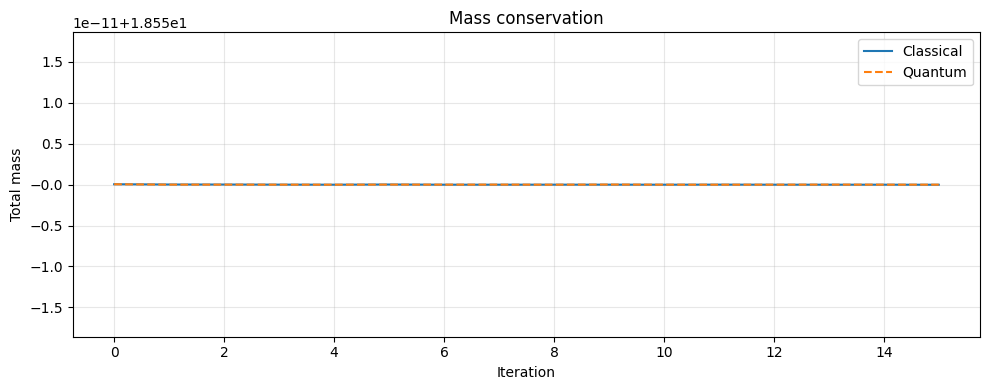

In [8]:
# Mass conservation check
classical_mass = df_c.sum(axis=1)
quantum_mass = df_q.sum(axis=1)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(classical_mass, label='Classical')
ax.plot(quantum_mass, label='Quantum', linestyle='--')
ax.set_xlabel('Iteration')
ax.set_ylabel('Total mass')
ax.set_title('Mass conservation')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"{dirname}/mass_conservation.png", dpi=300, bbox_inches='tight')
plt.show()